## Анализ ошибок

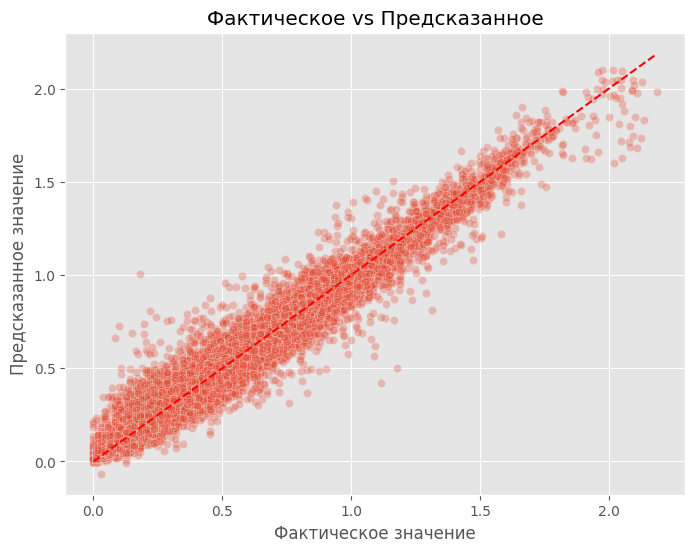

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактическое значение")
plt.ylabel("Предсказанное значение")
plt.title("Фактическое vs Предсказанное")
plt.grid(True)
plt.show()


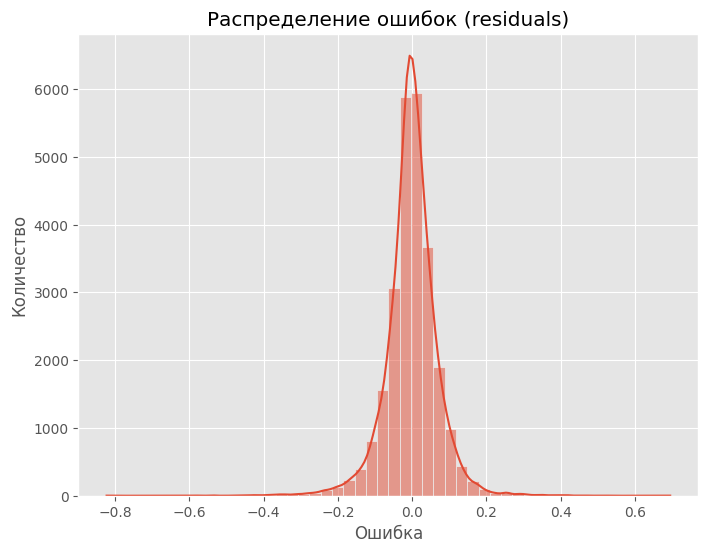

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Распределение ошибок (residuals)")
plt.xlabel("Ошибка")
plt.ylabel("Количество")
plt.grid(True)
plt.show()


In [ ]:
import optuna.visualization as vis

!pip install optuna-dashboard -q

# График важности гиперпараметров
vis.plot_param_importances(study).show()

# График оптимизации (как улучшалась метрика по итерациям)
vis.plot_optimization_history(study).show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.2/104.2 kB 8.6 MB/s eta 0:00:00


In [ ]:
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

print(f"Лучшее R² на валидации: {study.best_value:.4f}")

Лучшие параметры:
n_estimators: 376
max_depth: 10
learning_rate: 0.1987926076590788
num_leaves: 44
min_child_samples: 12
subsample: 0.9974907277457494
colsample_bytree: 0.6237098179233606
Лучшее R² на валидации: 0.9552


In [ ]:
import shap
explainer = shap.TreeExplainer(loaded_catboost)
shap_values = explainer.shap_values(X_train[:1000])

# Строим summary график
shap.summary_plot(shap_values, X_train[:1000], plot_type="bar")  # bar-график важности